In [1]:
from google.colab import files
uploaded = files.upload()

Saving train-images.idx3-ubyte to train-images.idx3-ubyte
Saving train-labels.idx1-ubyte to train-labels.idx1-ubyte
Saving t10k-images.idx3-ubyte to t10k-images.idx3-ubyte
Saving t10k-labels.idx1-ubyte to t10k-labels.idx1-ubyte


In [3]:
import numpy as np
import struct

def load_images(file_path):
    with open(file_path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_labels(file_path):
    with open(file_path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

In [4]:
x_train = load_images("train-images.idx3-ubyte")
y_train = load_labels("train-labels.idx1-ubyte")

x_test = load_images("t10k-images.idx3-ubyte")
y_test = load_labels("t10k-labels.idx1-ubyte")

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (60000, 28, 28)
Test: (10000, 28, 28)


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [6]:
from skimage.feature import local_binary_pattern

def extract_lbp_features(image):
    radius = 1
    n_points = 8 * radius

    lbp = local_binary_pattern(image, n_points, radius, method='uniform')

    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, n_points + 3),
                           range=(0, n_points + 2))

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist

In [7]:
num_samples = 2000  # keep small for speed

features = []
labels = []

for i in range(num_samples):
    feat = extract_lbp_features(x_train[i])
    features.append(feat)
    labels.append(y_train[i])

features = np.array(features)
labels = np.array(labels)

print(features.shape)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


(2000, 10)


In [8]:
from sklearn.metrics.pairwise import euclidean_distances

def retrieve_similar_images(query_img, features, top_k=5):

    query_feat = extract_lbp_features(query_img)

    dists = euclidean_distances([query_feat], features)[0]

    indices = np.argsort(dists)[:top_k]

    return indices

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


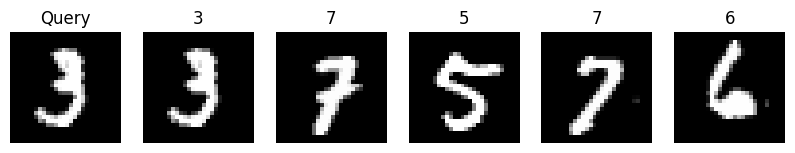

In [9]:
import matplotlib.pyplot as plt

query_index = 10
query_img = x_train[query_index]

indices = retrieve_similar_images(query_img, features, top_k=5)

plt.figure(figsize=(10,3))

# Query image
plt.subplot(1,6,1)
plt.imshow(query_img, cmap='gray')
plt.title("Query")
plt.axis('off')

# Retrieved images
for i, idx in enumerate(indices):
    plt.subplot(1,6,i+2)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(f"{labels[idx]}")
    plt.axis('off')

plt.show()

In [10]:
def compute_precision_recall(query_label, retrieved_indices, labels):

    # Count relevant retrieved
    relevant = 0
    for idx in retrieved_indices:
        if labels[idx] == query_label:
            relevant += 1

    # Precision
    precision = relevant / len(retrieved_indices)

    # Total relevant in dataset
    total_relevant = np.sum(labels == query_label)

    # Recall
    recall = relevant / total_relevant

    return precision, recall

In [11]:
def compute_ap(query_label, retrieved_indices, labels):

    correct = 0
    precision_sum = 0

    for i, idx in enumerate(retrieved_indices):
        if labels[idx] == query_label:
            correct += 1
            precision_at_i = correct / (i + 1)
            precision_sum += precision_at_i

    if correct == 0:
        return 0

    return precision_sum / correct

In [13]:
def evaluate_system(x_data, labels, features, num_queries=100, top_k=5):

    precisions = []
    recalls = []
    aps = []

    for i in range(num_queries):

        query_img = x_data[i]
        query_label = labels[i]

        retrieved = retrieve_similar_images(query_img, features, top_k)

        p, r = compute_precision_recall(query_label, retrieved, labels)
        ap = compute_ap(query_label, retrieved, labels)

        precisions.append(p)
        recalls.append(r)
        aps.append(ap)

    return np.mean(precisions), np.mean(recalls), np.mean(aps)

In [14]:
precision, recall, mAP = evaluate_system(x_train[:2000], labels, features)

print("Precision:", precision)
print("Recall:", recall)
print("mAP:", mAP)

/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

Precision: 0.424
Recall: 0.010463418024264062
mAP: 0.926861111111111


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3

In [16]:
def print_evaluation_table(precision, recall, mAP):

    print("\nComparative Analysis\n")

    # Header
    print("{:<10} {:<10} {:<10} {:<10} {:<15} {:<30}".format(
        "Method", "Precision", "Recall", "mAP", "Robustness", "Remarks"
    ))

    print("-" * 90)

    # Row for LBP
    print("{:<10} {:<10.2f} {:<10.2f} {:<10.2f} {:<15} {:<30}".format(
        "LBP",
        precision,
        recall,
        mAP,
        "Low",
        "Texture-based, no semantic understanding"
    ))

In [17]:
precision, recall, mAP = evaluate_system(x_train[:2000], labels, features)

print_evaluation_table(precision, recall, mAP)


Comparative Analysis

Method     Precision  Recall     mAP        Robustness      Remarks                       
------------------------------------------------------------------------------------------
LBP        0.42       0.01       0.93       Low             Texture-based, no semantic understanding


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
/usr/local/lib/python3